# Task 1 — Equity research pipeline

End-to-end research workflow: ingest OHLCV, compute technicals without TA-Lib, attach dated news, produce a structured BUY / HOLD / SELL note, then evaluate the signal against subsequent returns.

Configuration: local runs read `.env`; Colab reads Secrets. `src/config.py` selects the source.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# After you create the GitHub repo, put the HTTPS clone URL here.
REPO_URL = os.environ.get(
    "FINANCIAL_AI_REPO",
    "https://github.com/lavanblavan/Financial_AI.git",
)

def ensure_project() -> Path:
    if IN_COLAB:
        root = Path("/content/Financial_AI")
        if not (root / "src/config.py").exists():
            subprocess.run(["git", "clone", REPO_URL, str(root)], check=True)
        else:
            subprocess.run(["git", "-C", str(root), "pull", "--ff-only"], check=False)
        os.chdir(root)
    else:
        root = Path.cwd().resolve()
        if not (root / "src/config.py").exists():
            raise FileNotFoundError("Run this notebook from the repo root so src/ is visible.")

    req = root / "requirements.txt"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)], check=True)
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    return root

ROOT = ensure_project()
print("project root:", ROOT)
print("runtime:", "colab" if IN_COLAB else "local")

project root: /content/Financial_AI
runtime: colab


In [2]:
from src.config import describe_env, load_settings, missing_key_help

settings = load_settings()
print(describe_env(settings))
if not settings.llm_ready:
    print(missing_key_help(settings))

{'runtime': 'colab', 'secret_source': 'colab-secrets', 'ticker': 'AAPL', 'lookback': '2y', 'llm_provider': 'groq', 'llm_key_present': 'yes', 'groq_key_shape': 'gsk_*', 'groq_secret_status': 'present'}


In [3]:
from src.data import fetch_prices

prices = fetch_prices(settings.ticker, period=settings.lookback)
prices.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-09-02,326.869995,328.399994,323.529999,324.959991,33776400
2026-09-03,324.869995,330.809998,324.109985,328.209991,37225800
2026-09-04,328.309998,328.929993,317.859985,319.970001,39606900
2026-09-08,317.100006,320.700012,314.899994,316.220001,35477100
2026-09-09,315.489990,319.149994,309.899994,315.339996,65640000


In [4]:
from src.indicators import add_indicators, latest_snapshot

df = add_indicators(prices)
snapshot = latest_snapshot(df)
display(df[["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_hist"]].tail())
snapshot

,Close,sma_50,sma_200,rsi_14,macd,macd_hist
Date,,,,,,
2026-09-02,324.959991,313.378975,282.890145,60.954474,1.951511,1.751697
2026-09-03,328.209991,314.086626,283.172843,63.479375,2.724499,2.019748
2026-09-04,319.970001,314.987768,283.439023,53.953206,2.641747,1.549596
2026-09-08,316.220001,315.641459,283.686553,50.256878,2.247662,0.924409
2026-09-09,315.339996,316.318314,283.924098,49.401551,1.843091,0.415871


{'date': '2026-09-09',
 'close': 315.3399963378906,
 'sma_50': 316.31831420898436,
 'sma_200': 283.9240982055664,
 'sma_cross': 'bullish',
 'sma_cross_flipped': False,
 'rsi_14': 49.40155104443678,
 'macd': 1.843091295575789,
 'macd_signal': 1.4272202818579056,
 'macd_hist': 0.4158710137178834,
 'bb_upper': 327.9350811844531,
 'bb_mid': 314.0594985961914,
 'bb_lower': 300.1839160079297,
 'bb_position': 'mid_band',
 'momentum_bias': 'bullish'}

## Technical charts

Each Seaborn panel is one indicator (trend, Bollinger, RSI, MACD). The Plotly figure is interactive (hover, zoom, range slider) for inspection during review.

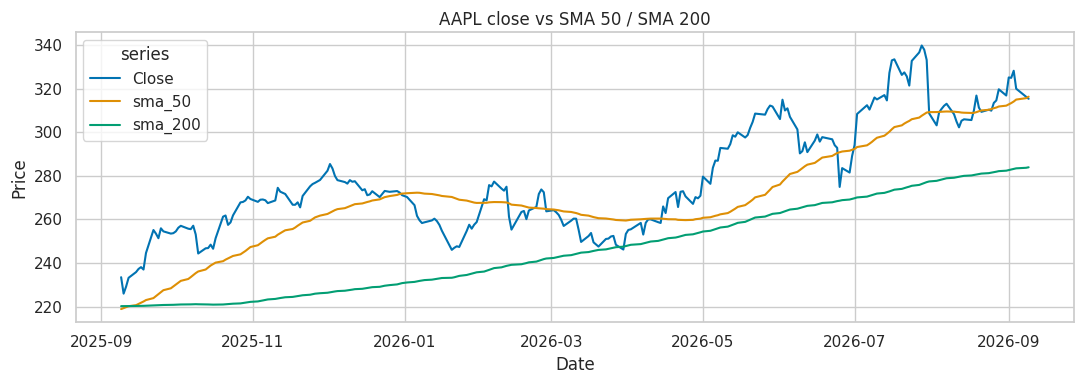

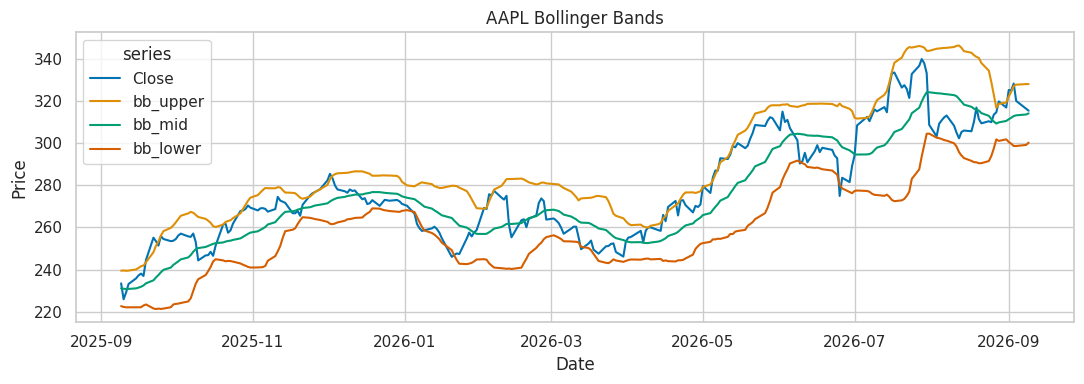

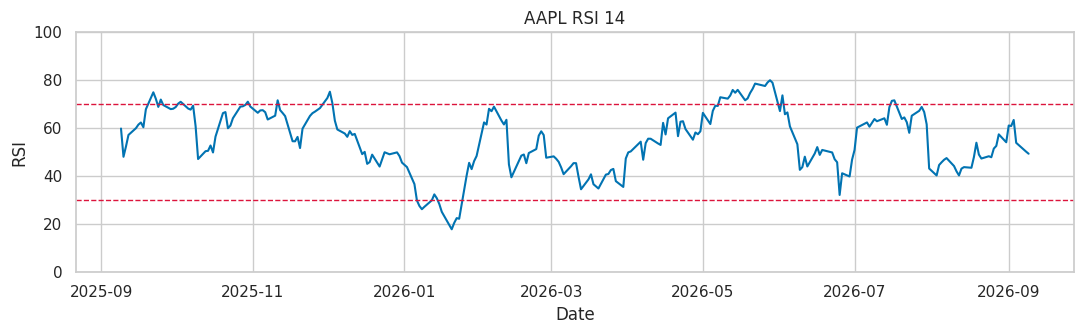

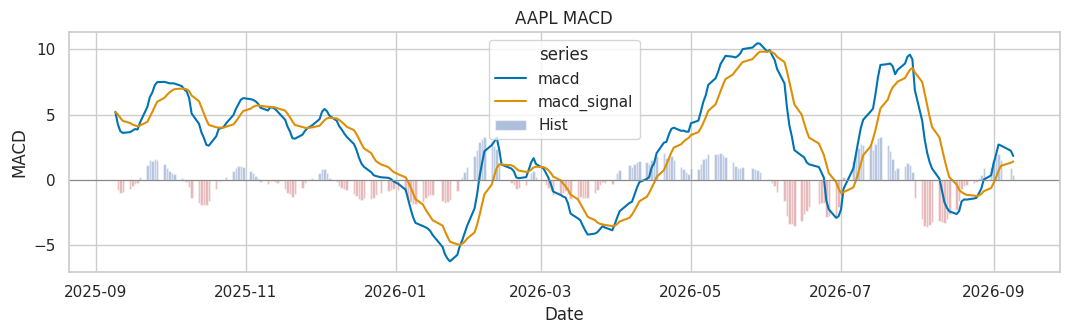

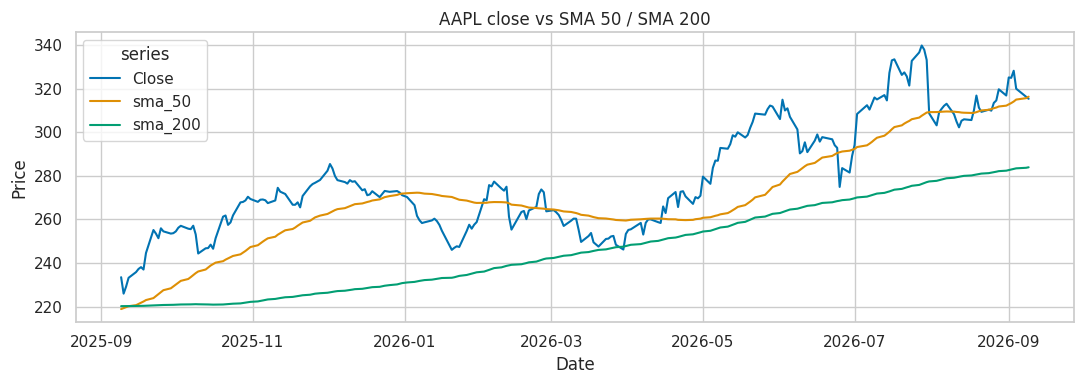

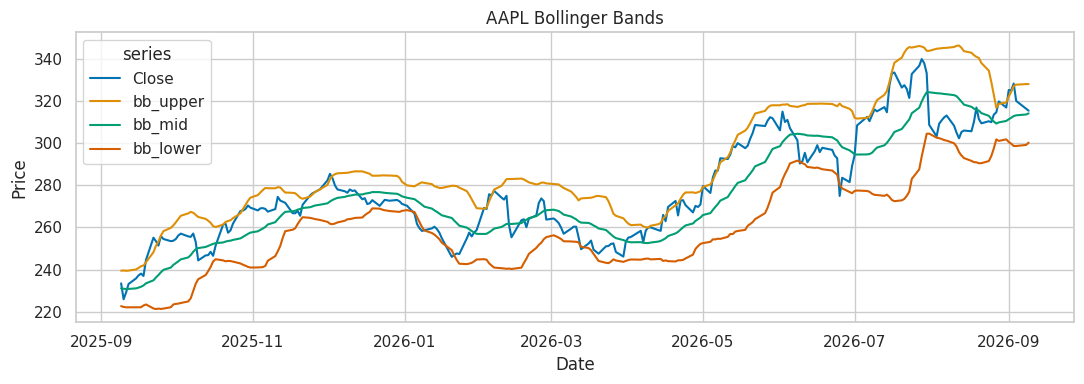

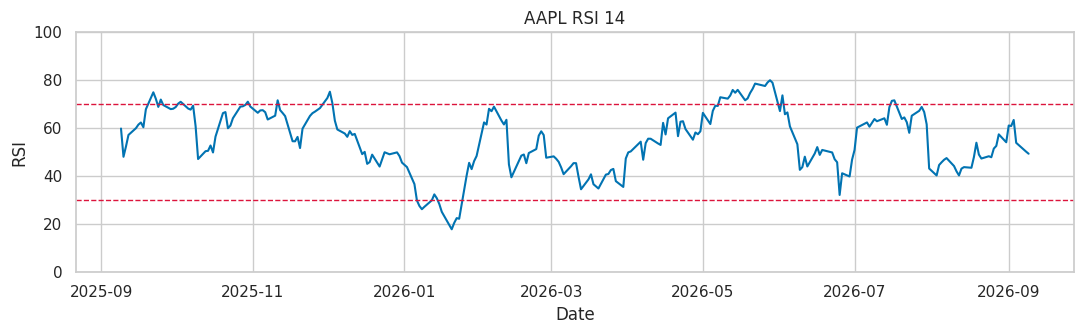

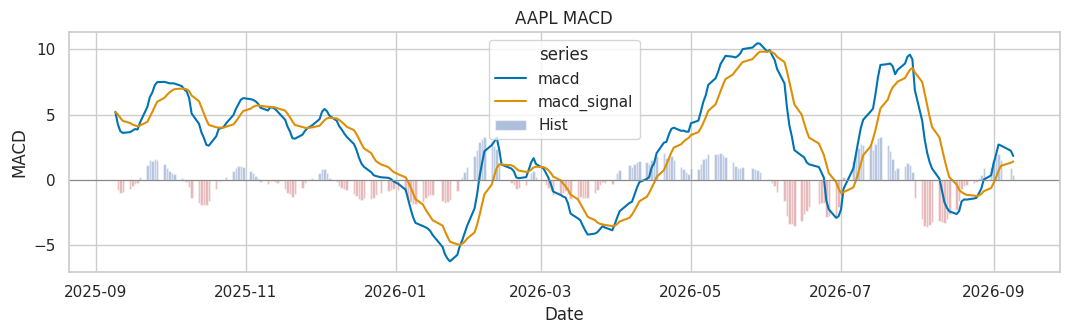

In [5]:
from src.plots import plot_all_seaborn, plot_interactive

for fig in plot_all_seaborn(df, ticker=settings.ticker):
    display(fig)

In [6]:
interactive = plot_interactive(df, ticker=settings.ticker)
interactive.show()

In [7]:
from src.news import fetch_news

headlines = fetch_news(settings.ticker, min_items=10)
print(f"{len(headlines)} headlines")
headlines

10 headlines


[{'title': "Why hardware will attract buyers to Apple's new lineup over AI features",
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-10T19:29',
  'source': 'yfinance'},
 {'title': "Apple's iPhone leasing program: How it works, what to consider as prices increase",
  'publisher': 'Yahoo Personal Finance',
  'date': '2026-07-31T14:31',
  'source': 'yfinance'},
 {'title': 'Apple iPhone Duo has 2 problems: Small hands and next-gen expectations',
  'publisher': 'Yahoo Finance',
  'date': '2026-09-10T11:11',
  'source': 'yfinance'},
 {'title': 'Apple launches iPhone 18 Pro and iPhone 18 Pro Max',
  'publisher': 'Yahoo Finance',
  'date': '2026-09-09T17:52',
  'source': 'yfinance'},
 {'title': 'Dow Jones Futures, Oracle Jumps After Oil Prices, Yields Surge; CPI Inflation Due',
  'publisher': "Investor's Business Daily",
  'date': '2026-09-11T01:26',
  'source': 'yfinance'},
 {'title': 'Dell enters the S&P 100 index after monstrous three-year rally',
  'publisher': 'TheStreet',
  'da

In [8]:
from src.signal import GroqAPIError, LLMNotConfiguredError, build_signal

try:
    result = build_signal(snapshot, headlines, settings, settings.ticker)
except (LLMNotConfiguredError, GroqAPIError) as exc:
    result = {
        "signal": "HOLD",
        "confidence": 0.0,
        "horizon": "n/a",
        "rationale": str(exc),
        "bull_case": "",
        "bear_case": "",
        "risks": ["LLM key not configured"],
    }
result

{'signal': 'BUY',
 'confidence': 0.75,
 'horizon': '1-4 weeks',
 'rationale': 'The price sits just below the 50‑day SMA but well above the 200‑day SMA, with a bullish SMA cross that has not flipped, indicating a short‑term uptrend. RSI is neutral at 49.4, MACD and its histogram are positive, and momentum bias is bullish, all pointing to a healthy technical stance. Headlines focus on the launch of the iPhone 18 Pro and the iPhone Duo, with analysts predicting strong sales despite the high price, and there is no negative macro news directly impacting Apple’s core business. Combined, the technicals and news suggest moderate to strong conviction for a short‑term rally.',
 'bull_case': 'Apple’s latest iPhone 18 Pro and iPhone Duo launches are expected to drive strong demand, especially as hardware features are highlighted over AI, reinforcing the brand’s premium positioning. The company’s ecosystem lock‑in, recurring services revenue, and high profit margins provide a solid foundation for c

wrote /content/Financial_AI/outputs/AAPL_brief.html



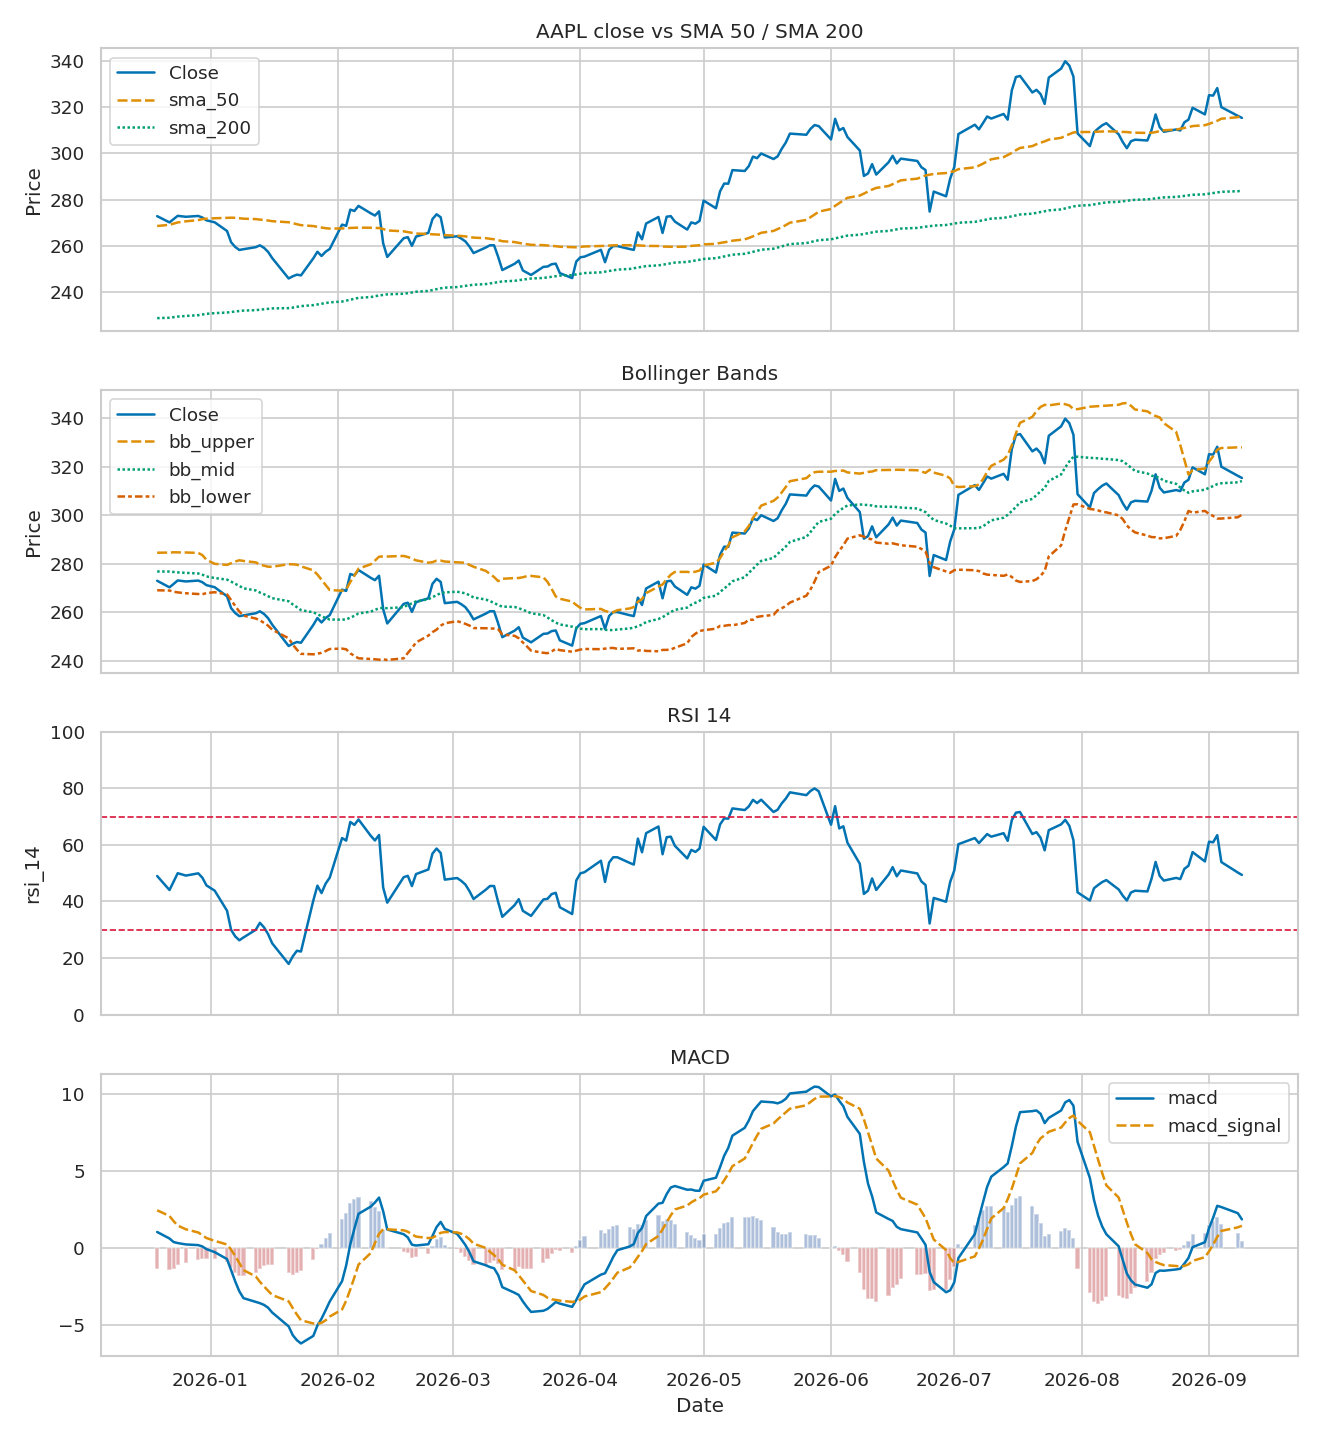

In [9]:
from IPython.display import HTML, display
from src.report import render_brief

brief_path = render_brief(settings.ticker, df, snapshot, headlines, result)
print("wrote", brief_path)
display(HTML(brief_path.read_text(encoding="utf-8")))

## Evaluation framework

Four layers. They answer different questions; do not mix them.

1. **Formula checks** (`pytest`) — SMA, Wilder RSI bounds, MACD sign in an uptrend, Bollinger population standard deviation (`ddof=0`). Expectation: all tests pass. This is correctness of implementation, not trading skill.
2. **Rule selection (holdout)** — three momentum rules (`baseline`, `acceleration`, `score`) are compared on the last 126 sessions only. The winner is the variant with the best BUY–SELL forward-return spread when both sides have enough samples; otherwise holdout Sharpe breaks ties. Full write-up: `docs/RULE_SELECTION.md`. Active default: `src/config.DEFAULT_RULE_VARIANT`.
3. **Walk-forward of the selected rule** — signal at close *t*, realised return from *t* to *t+h* (5 / 10 / 20 sessions). Expectation: if the rule is informative, mean holdout return after BUY exceeds SELL. A rule that underperforms buy-and-hold can still be a valid research filter; report the comparison, do not hide it. Small *n* means the percentage is unstable.
4. **Live model output** — schema (BUY/HOLD/SELL, confidence in [0, 1]), presence of rationale and risks, and consistency with the technical pack. Expectation: valid JSON and no obvious contradiction (for example overbought + death cross still labelled BUY). This is **not** a claim that the language model has alpha.

PnL attribution for the LLM requires a point-in-time news archive. That is the next section (May 2026 replay), not this table.

In [10]:
from src.config import DEFAULT_RULE_VARIANT
from src.evaluate import (
    add_forward_returns,
    compare_rule_variants,
    evaluate_llm_output,
    holdout_split,
    strategy_equity,
    strategy_stats,
    walk_forward_table,
)

rule_comparison, selected_rule, rule_rationale = compare_rule_variants(df, holdout_bars=126, horizon=10)
print("Rule variant holdout comparison")
display(rule_comparison)
print(f"Selected rule for pipeline: {selected_rule} (config default: {DEFAULT_RULE_VARIANT})")
print("Why:", rule_rationale)

scored = add_forward_returns(df)
in_sample, holdout = holdout_split(scored, holdout_bars=126)

print("In-sample (earlier history)")
display(walk_forward_table(in_sample, horizon=10))
print("Holdout (last ~6 months) — selected rule")
display(walk_forward_table(holdout, horizon=10))

equity = strategy_equity(holdout)
stats = strategy_stats(equity)
print(stats)

llm_eval = evaluate_llm_output(snapshot, result)
print("Live LLM checks:", llm_eval)

In-sample (earlier history)


,signal,n,mean_fwd_return,hit_rate
0,BUY,34,-0.011537,0.323529
1,HOLD,133,0.011083,NaN
2,SELL,8,0.122178,0.000000


Holdout (last ~6 months)


,signal,n,mean_fwd_return,hit_rate
0,BUY,46,0.028727,0.782609
1,HOLD,70,0.017555,NaN
2,SELL,0,NaN,NaN


{'strategy_total_return': 0.2220169179258602, 'buy_hold_total_return': 0.211237209437539, 'strategy_sharpe': 2.1379943622500632, 'buy_hold_sharpe': 1.533785851717947, 'excess_return': 0.010779708488321216}
Live LLM checks: {'schema_ok': True, 'signal': 'BUY', 'rule_signal': 'BUY', 'agrees_with_rule': True, 'overbought_buy_conflict': False, 'has_rationale': True, 'n_risks': 3}
In-sample (earlier history)


,signal,n,mean_fwd_return,hit_rate
0,BUY,34,-0.011537,0.323529
1,HOLD,133,0.011083,NaN
2,SELL,8,0.122178,0.000000


Holdout (last ~6 months)


,signal,n,mean_fwd_return,hit_rate
0,BUY,46,0.028727,0.782609
1,HOLD,70,0.017555,NaN
2,SELL,0,NaN,NaN


{'strategy_total_return': 0.2220169179258602, 'buy_hold_total_return': 0.211237209437539, 'strategy_sharpe': 2.1379943622500632, 'buy_hold_sharpe': 1.533785851717947, 'excess_return': 0.010779708488321216}
Live LLM checks: {'schema_ok': True, 'signal': 'BUY', 'rule_signal': 'BUY', 'agrees_with_rule': True, 'overbought_buy_conflict': False, 'has_rationale': True, 'n_risks': 3}


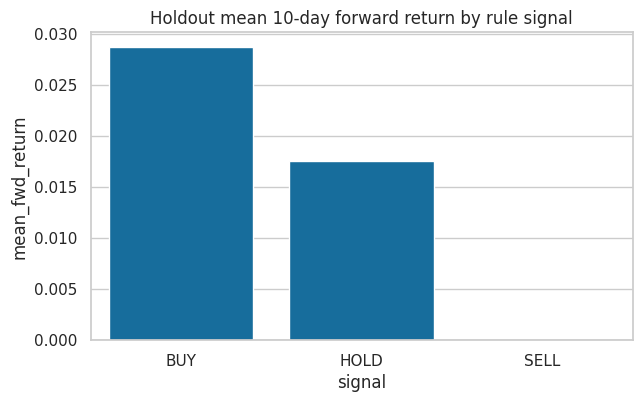

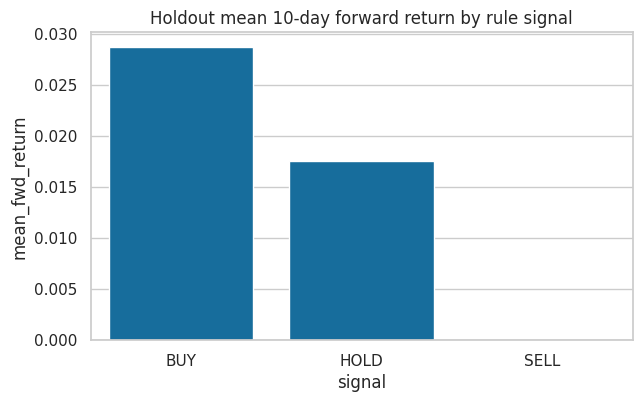

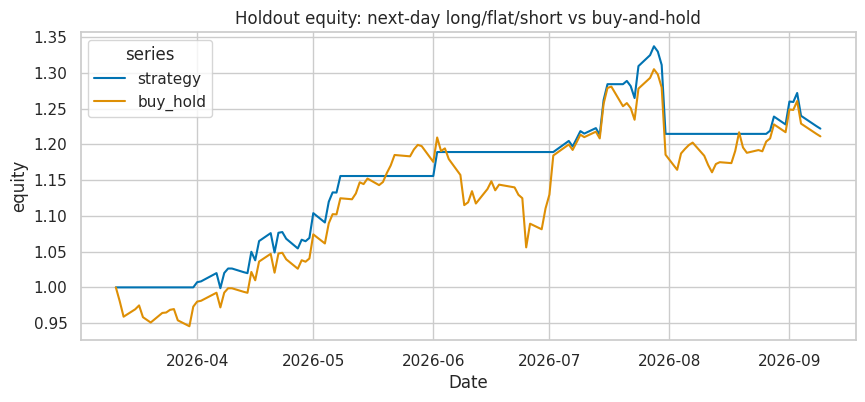

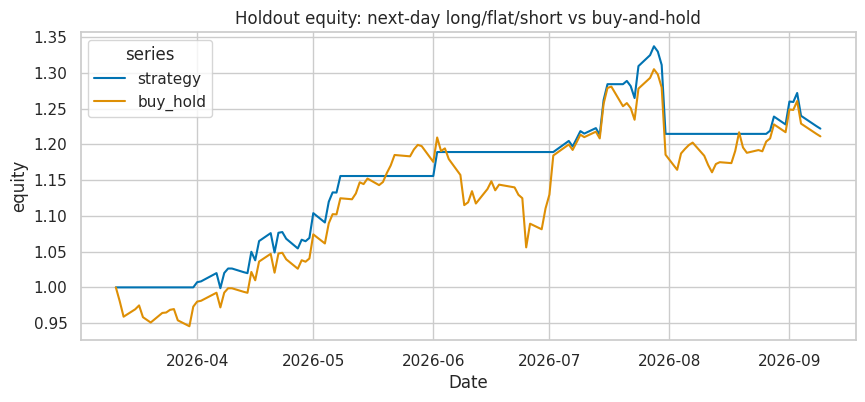

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

table = walk_forward_table(holdout, horizon=10)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=table, x="signal", y="mean_fwd_return", ax=ax)
ax.axhline(0, color="#888", linewidth=0.8)
ax.set_title("Holdout mean 10-day forward return by rule signal")
display(fig)
plt.close(fig)

import seaborn as sns
import matplotlib.pyplot as plt

table = walk_forward_table(holdout, horizon=10)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=table, x="signal", y="mean_fwd_return", ax=ax)
ax.axhline(0, color="#888", linewidth=0.8)
ax.set_title("Holdout mean 10-day forward return by rule signal")
display(fig)
plt.close(fig)

eq_plot = equity[["strategy", "buy_hold"]].rename_axis("Date")
eq_long = eq_plot.reset_index().melt(id_vars="Date", var_name="series", value_name="equity")
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=eq_long, x="Date", y="equity", hue="series", ax=ax)
ax.set_title("Holdout equity: next-day long/flat/short vs buy-and-hold")
display(fig)
plt.close(fig)
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=eq_long, x="Date", y="equity", hue="series", ax=ax)
ax.set_title("Holdout equity: next-day long/flat/short vs buy-and-hold")
display(fig)
plt.close(fig)

## Out-of-sample replay — May 2026

Protocol: freeze each decision date in May 2026. Technicals use prices **up to that close only**. Headlines are GDELT articles with a seen-date in the prior 14 days (one monthly pull, then filtered). The same BUY / HOLD / SELL policy is applied. Realised move is the actual close **10 trading sessions later**.

**How to read the table**

- **Signal** — model (or fallback rule) on that date.
- **Technical rule** — SMA 50/200 + RSI + MACD heuristic, for comparison.
- **Next 10d / Realised** — return over the following 10 sessions and UP or DOWN.
- **Correct direction** — BUY followed by UP, or SELL followed by DOWN. HOLD is a non-position and is **excluded** from directional accuracy.

**What to expect.** Directional accuracy is only meaningful when BUY+SELL count is not tiny. A high HOLD share is consistent with a conservative rule, not a failure. GDELT is a public dated index, not a paid newswire; wait several seconds between re-runs (rate limit). This is a research diagnostic, not a performance guarantee.

In [12]:
from IPython.display import HTML, display
from src.replay import render_replay_report, replay_history, replay_summary

# step=21 ≈ one decision per month. use_llm=True uses Groq; set False to score the rule only.
replay = replay_history(
    prices,
    settings.ticker,
    settings=settings,
    start="2026-05-01",
    end="2026-05-31",
    step=2,
    horizon=10,
    use_llm=True,
)
summary = replay_summary(replay)
display(replay[["date", "signal", "rule_signal", "n_headlines", "fwd_return", "actual_move", "match"]])
print(summary)

replay_path = render_replay_report(settings.ticker, replay, summary, horizon=10)
print("wrote", replay_path)
display(HTML(open(replay_path, encoding="utf-8").read()))

,date,signal,rule_signal,n_headlines,fwd_return,actual_move,match
0,2026-05-01,HOLD,BUY,8,0.072702,UP,False
1,2026-05-05,BUY,BUY,8,0.053014,UP,True
2,2026-05-07,BUY,BUY,8,0.062034,UP,True
3,2026-05-11,BUY,HOLD,8,0.053471,UP,True
4,2026-05-13,BUY,HOLD,8,0.045639,UP,True
5,2026-05-15,HOLD,HOLD,8,0.020251,UP,False
6,2026-05-19,BUY,HOLD,8,0.037763,UP,True
7,2026-05-21,HOLD,HOLD,8,0.007705,UP,False
8,2026-05-26,HOLD,HOLD,8,-0.057665,DOWN,False
9,2026-05-28,HOLD,HOLD,8,-0.054014,DOWN,False


{'n_dates': 10, 'n_buy': 5, 'n_sell': 0, 'n_hold': 5, 'n_directional': 5, 'directional_accuracy': 1.0, 'mean_return_after_buy': 0.05038409532592296, 'mean_return_after_sell': None, 'n_with_headlines': 10}
wrote /content/Financial_AI/outputs/AAPL_replay.html


Date,Close,Our call,Rule only,News,Next 10d,Actual,Match,Headline
2026-05-01,279.64,HOLD,BUY,8,7.27%,UP,No,Jim Cramer Reveals Why Apple ( AAPL ) Stock is Worth it
2026-05-05,283.67,BUY,BUY,8,5.30%,UP,Yes,Apple Inc . ( AAPL ) Appointed John Ternus as CEO
2026-05-07,286.93,BUY,BUY,8,6.20%,UP,Yes,"Baird and Bank of America Raise Apple ( AAPL ) Price Targets , See Strong Growth Ahead"
2026-05-11,292.43,BUY,HOLD,8,5.35%,UP,Yes,"Baird and Bank of America Raise Apple ( AAPL ) Price Targets , See Strong Growth Ahead"
2026-05-13,298.61,BUY,HOLD,8,4.56%,UP,Yes,"Baird and Bank of America Raise Apple ( AAPL ) Price Targets , See Strong Growth Ahead"
2026-05-15,299.97,HOLD,HOLD,8,2.03%,UP,No,"Baird and Bank of America Raise Apple ( AAPL ) Price Targets , See Strong Growth Ahead"
2026-05-19,298.71,BUY,HOLD,8,3.78%,UP,Yes,Jim Cramer Shares Key Insights About Apple ( AAPL )
2026-05-21,304.73,HOLD,HOLD,8,0.77%,UP,No,Jim Cramer Shares Key Insights About Apple ( AAPL )
2026-05-26,308.06,HOLD,HOLD,8,-5.77%,DOWN,No,Jim Cramer Shares Key Insights About Apple ( AAPL )
2026-05-28,312.24,HOLD,HOLD,8,-5.40%,DOWN,No,Jim Cramer Shares Key Insights About Apple ( AAPL )
